In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch

# load the dataset
df = pd.read_csv("../datasets/diabetes_prediction_dataset.csv", index_col=0)

# Handle Gender and Smoking History with One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'], dtype=int)
print(f"Original columns ({len(df.columns)}): {df.columns}")
print(f"Encoded columns ({len(df.columns)}): {df_encoded.columns}")

print(f"# rows: {len(df)}")
print(f"positive rate: {df['diabetes'].mean()}")

Original columns (9): Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')
Encoded columns (9): Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male',
       'gender_Other', 'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current'],
      dtype='str')
# rows: 100000
positive rate: 0.085


In [4]:
# 2. Split Features and Target
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

print(df_encoded.head())

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Scaling: ONLY scale continuous numbers, not the 0/1 one-hot columns
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
scaler = StandardScaler()
X_train_raw[num_cols] = scaler.fit_transform(X_train_raw[num_cols])
X_test_raw[num_cols] = scaler.transform(X_test_raw[num_cols])

# 4. Convert to Tensors
X_train = torch.tensor(X_train_raw.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)

X_test = torch.tensor(X_test_raw.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Female  gender_Male  gender_Other  \
0         0              1            0             0   
1         0              1            0             0   
2         0              0            1             0   
3         0              1            0             0   
4         0              0            1             0   

   smoking_history_No Info  smoking_history_current  smoking_history_ever  \
0                        0                        0                     0   
1               

In [5]:
import torch.nn as nn
class DiabetesClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DiabetesClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32) # For batch normalization
        self.layer2 = nn.Linear(32, 16)
        self.dropout = nn.Dropout(0.2) # For regularization
        self.output = nn.Linear(16, num_classes)
        self.relu = nn.ReLU()

    # without batch normalization and dropout
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        return self.output(x) # Returns "Logits", since nn.CrossEntropyLoss() already includes softmax.

    # with batch normalization and dropout
    # def forward(self, x):
    #     x = self.relu(self.bn1(self.layer1(x)))
    #     x = self.dropout(self.relu(self.layer2(x)))
    #     return self.output(x) # Returns "Logits", since nn.CrossEntropyLoss() already includes softmax.


In [16]:
print(f"input dimensions: {X_train.shape}")
model = DiabetesClassifier(input_dim=X_train.shape[1], num_classes=2)
print("Layer 1:", model.layer1)
print("Layer 1 W matrix shape:", model.layer1.weight.shape)
print("Layer 1 bias vector shape:", model.layer1.bias.shape)

input dimensions: torch.Size([80000, 15])
Layer 1: Linear(in_features=15, out_features=32, bias=True)
Layer 1 W matrix shape: torch.Size([32, 15])
Layer 1 bias vector shape: torch.Size([32])


In [19]:

from sklearn.metrics import roc_auc_score, precision_score, recall_score


def get_metrics(model, X, y, criterion, calc_auc=True):
    """
    Computes both accuracy and loss for a given model and dataset.
    Useful for tracking progress and detecting overfitting.
    """
    # Switch the model to eval mode.
    model.eval()
    # The model should not update the gradients when evaluating.
    with torch.no_grad():
        # 1. Forward pass to get logits
        logits = model(X)

        # 2. Compute Loss (must use the same criterion as training)
        loss = criterion(logits, y).item()

        # 3. Compute Probabilities for AUC
        # We apply softmax and take the 2nd column (index 1) for the positive class
        probs = torch.softmax(logits, dim=1)[:, 1]

        # Hard predictions for Accuracy, Precision, Recall
        _, predicted = torch.max(logits, dim=1)
        y_pred = predicted.cpu().numpy()
        y_true = y.cpu().numpy()

        # Metrics
        accuracy = (y_pred == y_true).mean() * 100
        auc = 0
        if calc_auc:
            auc = roc_auc_score(y_true, probs)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

    return loss, accuracy, auc, precision, recall



In [20]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

model = DiabetesClassifier(input_dim=X_train.shape[1], num_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



# 1. Create a "Suitcase" for your data
train_ds = TensorDataset(X_train, y_train)

# 2. Create the "Conveyor Belt" (The DataLoader)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# Initialize lists to store the history
train_metrics = []
test_metrics = []

# 3. Training loop with batches (stochastic GD)
num_epochs = 1 #30
for epoch in range(num_epochs):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for batch_X, batch_y in loop:  # This loops 2500 times per epoch (80K/32)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())
    # Evaluation for this epoch
    train_metrics.append(get_metrics(model, X_train, y_train, criterion, calc_auc=True))
    test_metrics.append(get_metrics(model, X_test, y_test, criterion))

In [30]:
# After training a little, let's examine the gradient

print("Gradient needed for layer 1's weight matrix?", model.layer1.weight.requires_grad)
print("Layer1 gradient shape", model.layer1.weight.grad.shape)
print("Layer1 gradient first row:", model.layer1.weight.grad[0])
print("versus Layer1 weights first row", model.layer1.weight[0])

Gradient needed for layer 1's weight matrix? True
Layer1 gradient shape torch.Size([32, 15])
Layer1 gradient first row: tensor([ 2.3843e-04, -2.4295e-04, -2.8149e-04,  3.3642e-03,  9.4634e-04,
        -5.3630e-04,  6.6124e-04,  2.5549e-04,  0.0000e+00, -5.2080e-04,
        -2.8397e-05, -4.3679e-05, -5.6491e-06,  2.3097e-03, -7.9444e-04])
versus Layer1 weights first row tensor([-0.3173, -0.2537,  0.1153,  0.1367, -0.0614,  0.3078, -0.1241,  0.0123,
        -0.1187,  0.1290, -0.0437,  0.1205, -0.0665,  0.1038, -0.0187],
       grad_fn=<SelectBackward0>)


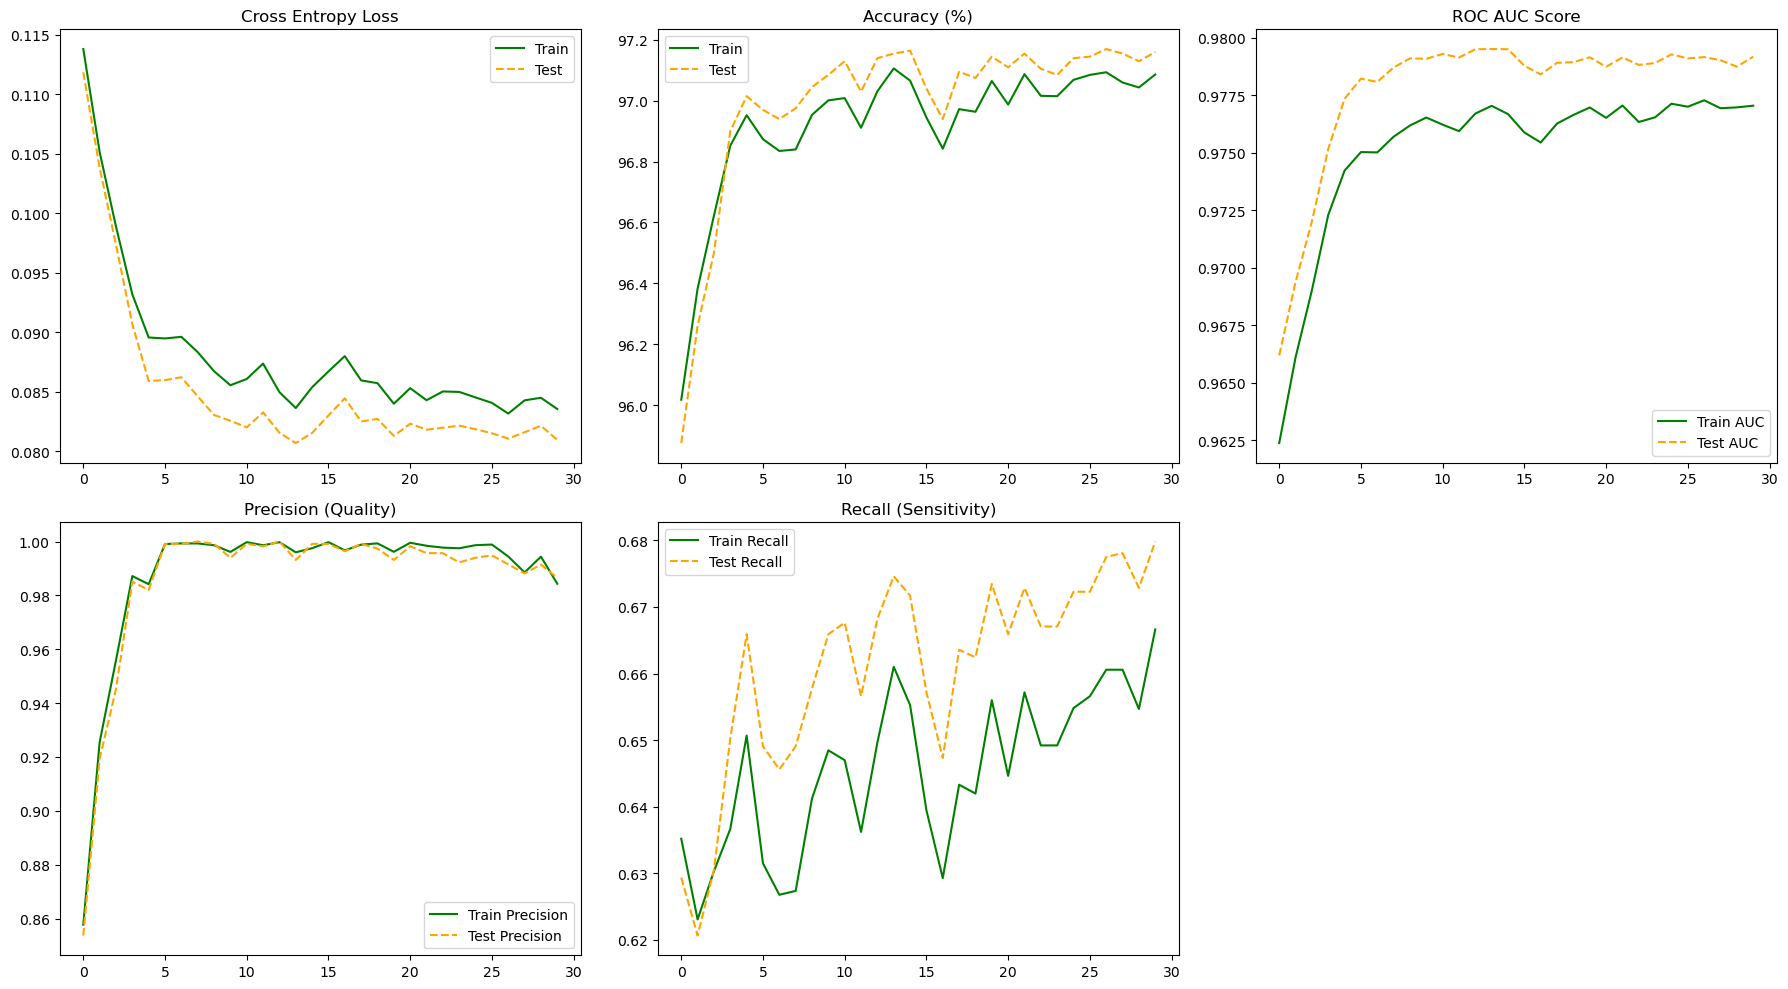

In [9]:
import matplotlib.pyplot as plt

def get_index_from_metrics(metrics_history, index):
    return [m[index] for m in metrics_history]

train_losses = get_index_from_metrics(train_metrics, 0)
test_losses = get_index_from_metrics(test_metrics, 0)
train_accs = get_index_from_metrics(train_metrics, 1)
test_accs = get_index_from_metrics(test_metrics, 1)
train_aucs = get_index_from_metrics(train_metrics, 2)
test_aucs = get_index_from_metrics(test_metrics, 2)
train_precs = get_index_from_metrics(train_metrics, 3)
test_precs = get_index_from_metrics(test_metrics, 3)
train_recalls = get_index_from_metrics(train_metrics, 4)
test_recalls = get_index_from_metrics(test_metrics, 4)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to 1D array for easier indexing

# 1. LOSS
axes[0].plot(train_losses, label='Train', color='green')
axes[0].plot(test_losses, label='Test', color='orange', linestyle='--')
axes[0].set_title('Cross Entropy Loss')
axes[0].legend()

# 2. ACCURACY
axes[1].plot(train_accs, label='Train', color='green')
axes[1].plot(test_accs, label='Test', color='orange', linestyle='--')
axes[1].set_title('Accuracy (%)')
axes[1].legend()

# 3. AUC
axes[2].plot(train_aucs, label='Train AUC', color='green')
axes[2].plot(test_aucs, label='Test AUC', color='orange', linestyle='--')
axes[2].set_title('ROC AUC Score')
axes[2].legend()

# 4. PRECISION
axes[3].plot(train_precs, label='Train Precision', color='green')
axes[3].plot(test_precs, label='Test Precision', color='orange', linestyle="--")
axes[3].set_title('Precision (Quality)')
axes[3].legend()

# 5. RECALL
axes[4].plot(train_recalls, label='Train Recall', color='green')
axes[4].plot(test_recalls, label='Test Recall', color='orange', linestyle="--")
axes[4].set_title('Recall (Sensitivity)')
axes[4].legend()

# Hide the unused 6th subplot
axes[5].axis('off')

# Final formatting
plt.tight_layout()
plt.show()